In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib


In [2]:

def obtener_rutas_imagenes():
    """
    Carga todas las imágenes válidas de data/raw/Original
    """
    # IMPORTANTE: Asegúrate de que esta ruta sea la correcta en tu PC
    RAW_PATH = Path('../data/raw/Original')
    CLASES   = ['Benign', 'Early', 'Pre', 'Pro']

    dataset = {}
    for cls in CLASES:
        carpeta = RAW_PATH / cls
        imgs = list(carpeta.glob('*.jpg')) + list(carpeta.glob('*.png'))
        imgs_validas = []
        for p in imgs:
            img = cv2.imread(str(p))
            # Verificamos que la imagen se lea bien y no esté corrupta/negra
            if img is not None and img.mean() >= 5:
                imgs_validas.append(p)
        dataset[cls] = imgs_validas

    todas = [p for paths in dataset.values() for p in paths]

    print('Dataset cargado:')
    for cls, imgs in dataset.items():
        print(f'  {cls:<10}: {len(imgs)} imágenes')
    print(f'  {"Total":<10}: {len(todas)} imágenes')

    return dataset, todas

# Ejecutamos la función
dataset, todas_las_rutas = obtener_rutas_imagenes()

Dataset cargado:
  Benign    : 504 imágenes
  Early     : 985 imágenes
  Pre       : 963 imágenes
  Pro       : 804 imágenes
  Total     : 3256 imágenes


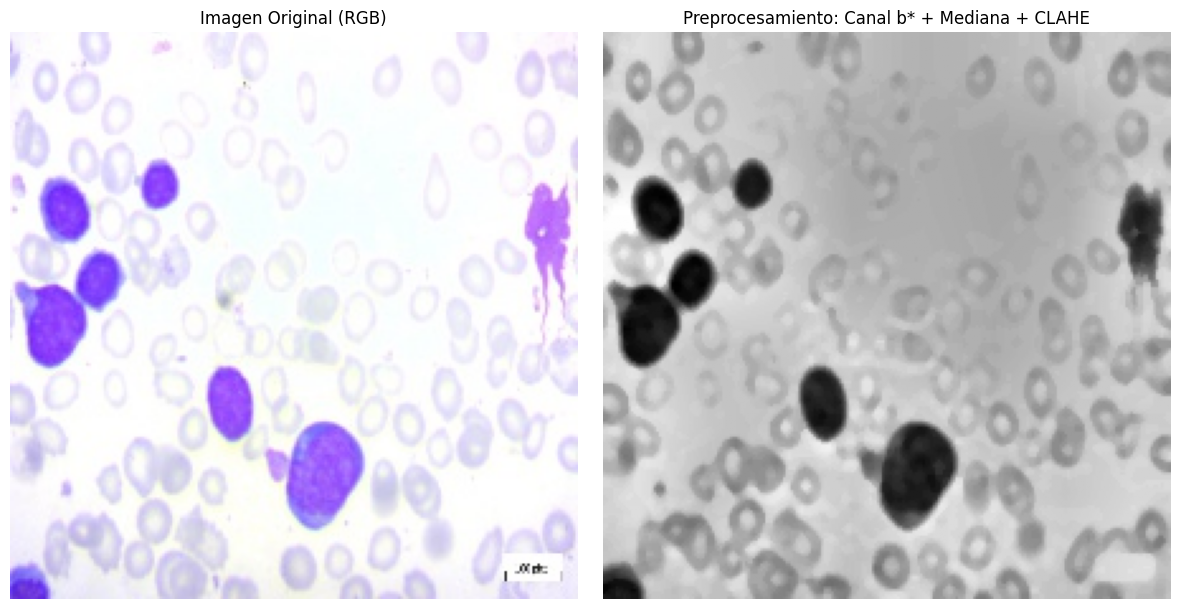

In [3]:
def preprocesar_imagen(ruta):
    """
    Toma la ruta de una imagen, la lee, cambia de espacio de color, 
    reduce el ruido y mejora el contraste del núcleo.
    """
    # 1. Leer imagen
    img_bgr = cv2.imread(str(ruta))
    # Convertir a RGB para que matplotlib la muestre con los colores reales
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 2. Convertir a espacio de color CIE L*a*b*
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    # Separar los canales L, a, b. 
    # El canal 'b*' resalta muy bien los núcleos púrpuras/azules frente al fondo
    l, a, b = cv2.split(img_lab)
    
    # 3. Filtrado de ruido con Filtro de Mediana
    # Suaviza el interior de la célula sin difuminar los bordes (kernel 5x5)
    b_suavizado = cv2.medianBlur(b, 5)
    
    # 4. Mejora de Contraste con CLAHE
    # Ayuda a homogeneizar la iluminación y marcar mejor los límites
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    canal_listo = clahe.apply(b_suavizado)
    
    return img_rgb, canal_listo

# Tomamos la primera imagen válida de nuestro dataset para hacer la prueba
ruta_prueba = todas_las_rutas[0]
img_original, img_preprocesada = preprocesar_imagen(ruta_prueba)

# -- Visualización --
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_original)
ax[0].set_title("Imagen Original (RGB)")
ax[0].axis("off")

# Mostramos el canal resultante usando un mapa de grises
ax[1].imshow(img_preprocesada, cmap="gray")
ax[1].set_title("Preprocesamiento: Canal b* + Mediana + CLAHE")
ax[1].axis("off")

plt.tight_layout()
plt.show()

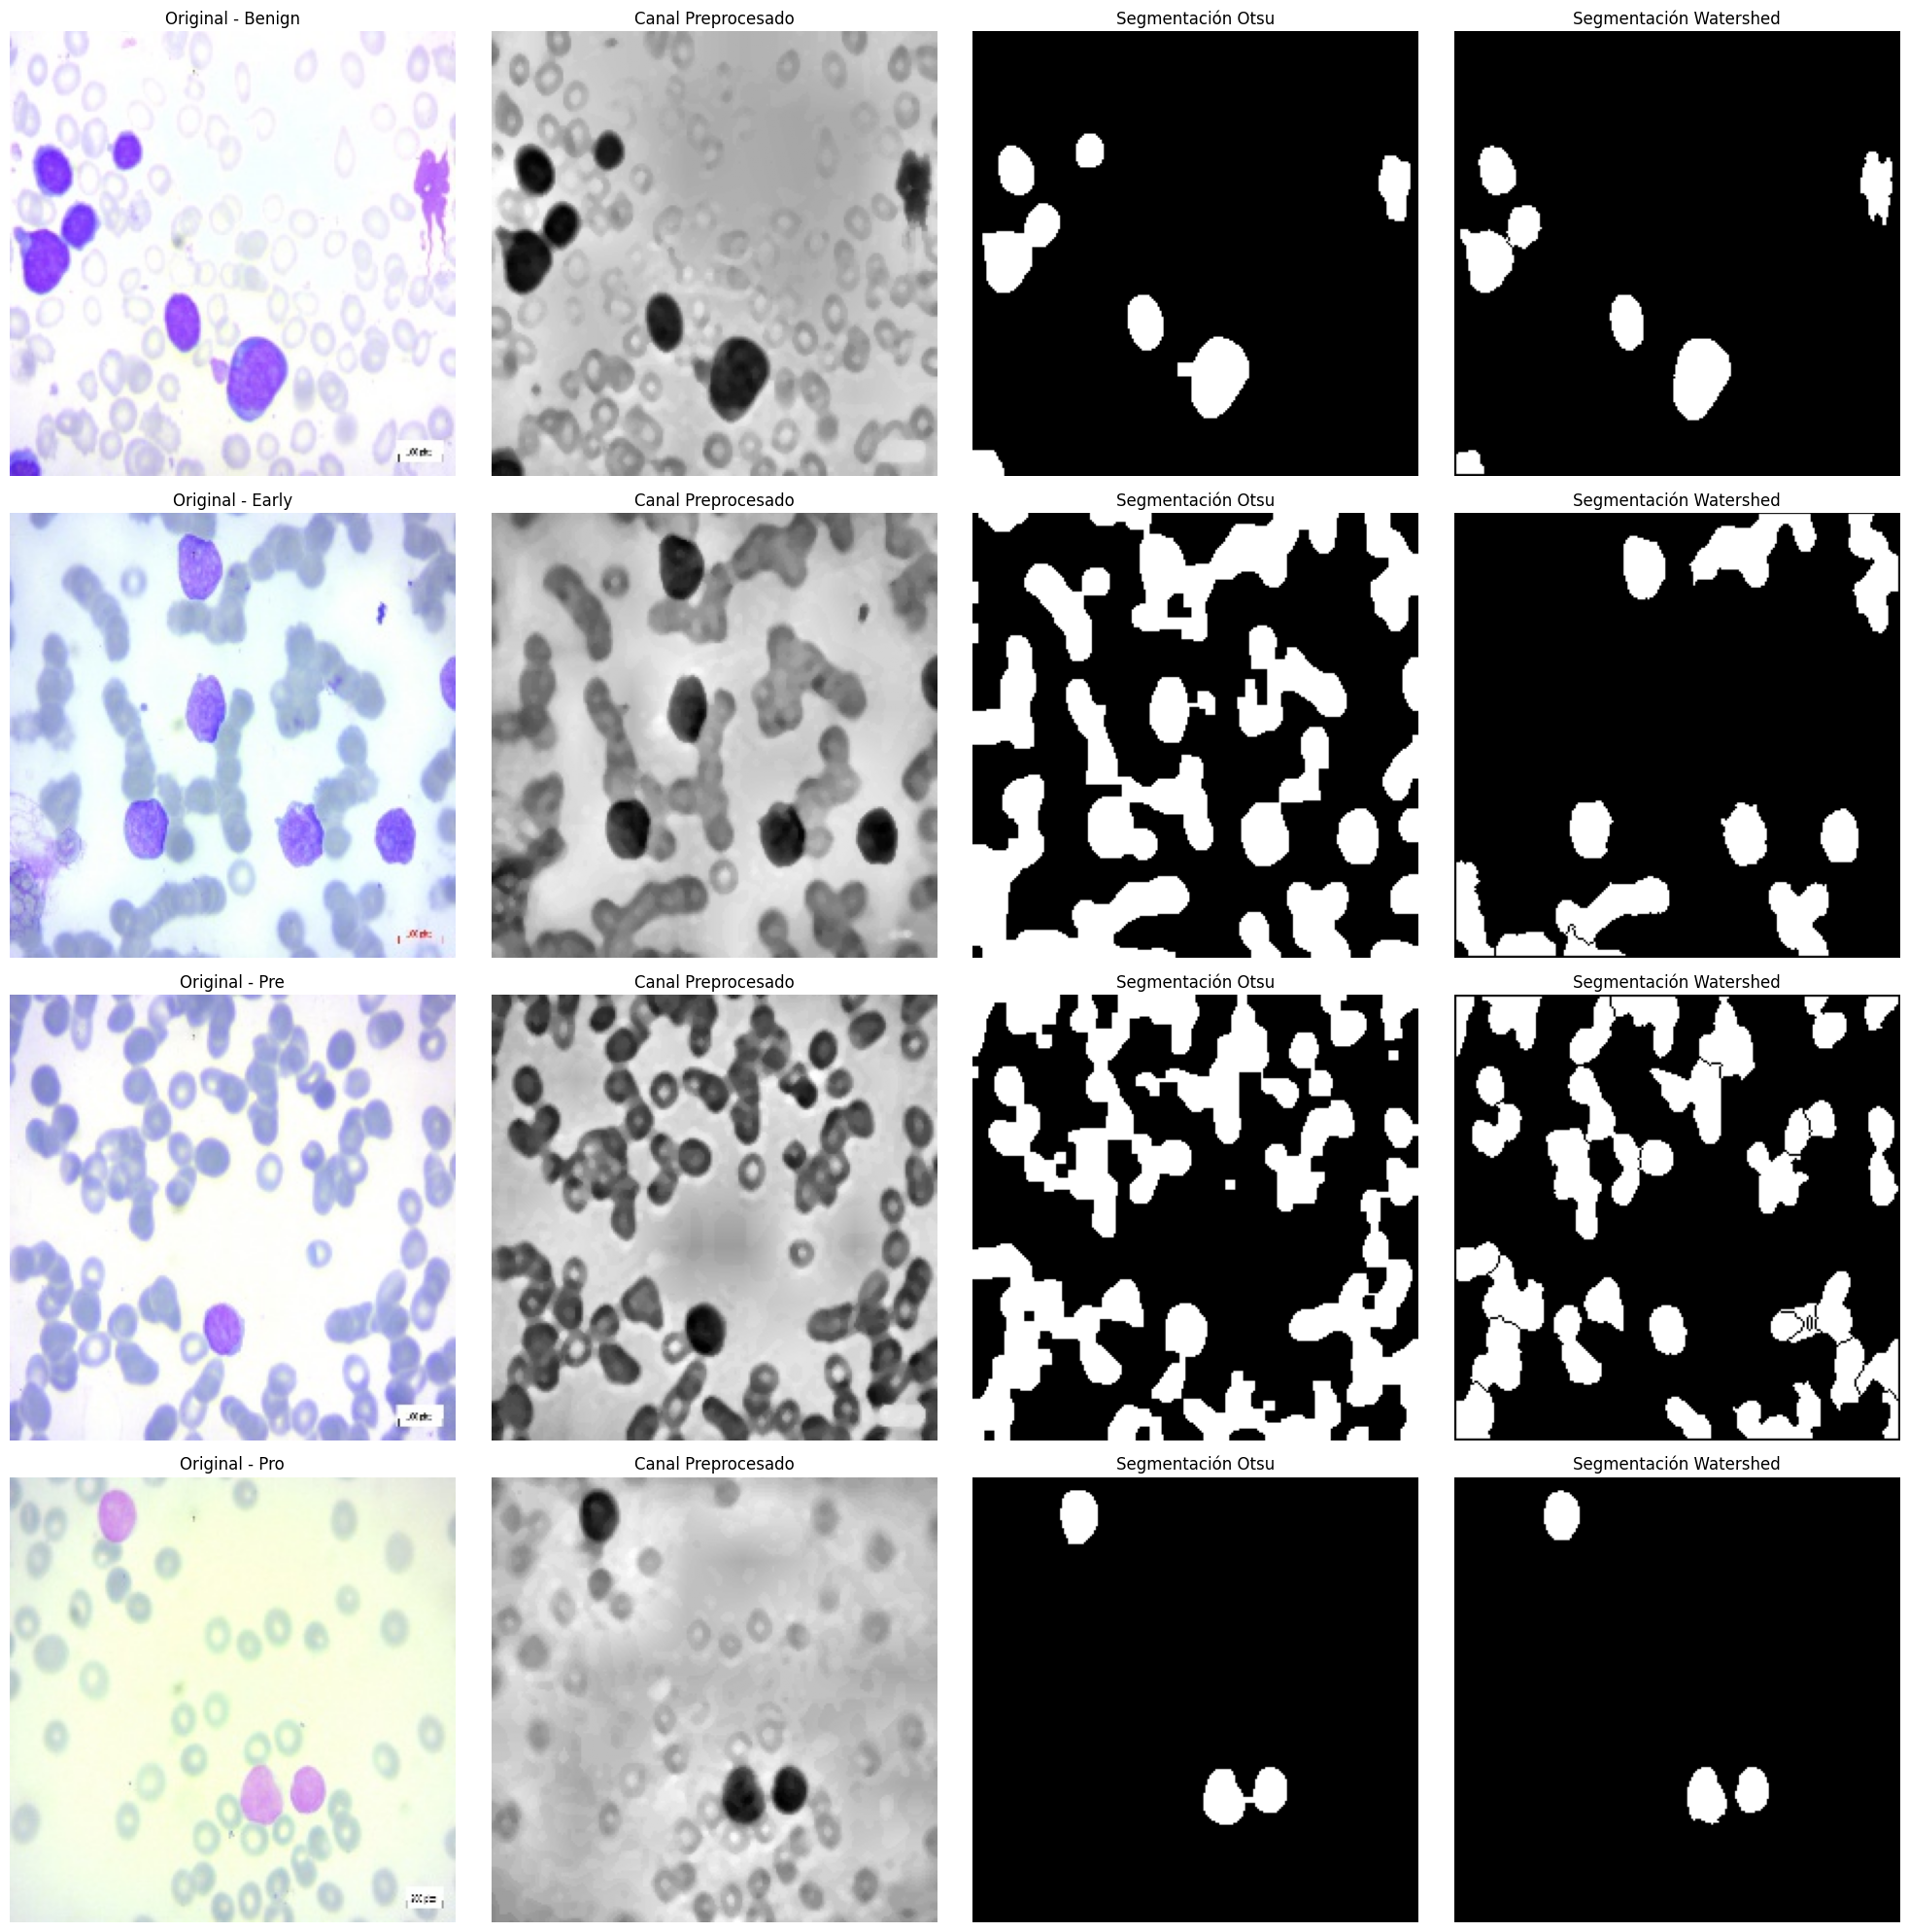

In [4]:
def segmentar_otsu_vs_watershed(img_rgb, canal_preprocesado, fg_factor=0.6):
    """
    Aplica segmentación. Permite ajustar qué tan estricto es Watershed 
    para definir el centro "seguro" del núcleo a través de fg_factor.
    """
    # ---------------------------------------------------------
    # 1. MÉTODO OTSU (Lo dejamos limpio, solo para generar la base)
    # ---------------------------------------------------------
    _, mask_otsu = cv2.threshold(canal_preprocesado, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((3,3), np.uint8)
    mask_otsu = cv2.morphologyEx(mask_otsu, cv2.MORPH_OPEN, kernel, iterations=2)
    mask_otsu = cv2.morphologyEx(mask_otsu, cv2.MORPH_CLOSE, kernel, iterations=2)

    # ---------------------------------------------------------
    # 2. MÉTODO WATERSHED CON BARRERA AJUSTABLE
    # ---------------------------------------------------------
    # Fondo seguro (dilatamos la máscara base)
    sure_bg = cv2.dilate(mask_otsu, kernel, iterations=3)
    
    # Transformada de distancia (encuentra los "centros" más gruesos)
    dist_transform = cv2.distanceTransform(mask_otsu, cv2.DIST_L2, 5)
    
    # NUEVO: Aquí aplicamos tu barrera (fg_factor). 
    # Multiplicamos el valor máximo por este factor.
    # Valores más cercanos a 1.0 son EXTREMADAMENTE estrictos.
    _, sure_fg = cv2.threshold(dist_transform, fg_factor * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    # Región dudosa
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    # Etiquetamos los marcadores
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1 
    markers[unknown == 255] = 0 
    
    # Aplicamos Watershed
    img_ws = img_rgb.copy()
    markers = cv2.watershed(img_ws, markers)
    
    # Reconstruimos la máscara
    mask_watershed = np.zeros_like(canal_preprocesado, dtype=np.uint8)
    mask_watershed[markers > 1] = 255 
    
    return mask_otsu, mask_watershed


# Sumamos 20 al umbral para forzar a que tome más píxeles como núcleo mask_otsu, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, ajuste_otsu=20)
    
    # =========================================================
# VISUALIZACIÓN COMPARATIVA (Grid de 4x4)
# =========================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for i, (clase, rutas) in enumerate(dataset.items()):
    if len(rutas) > 0:
        ruta_prueba = rutas[0]
        
        # 1. Preprocesamiento (usamos la función de la celda 2)
        img_original, img_preprocesada = preprocesar_imagen(ruta_prueba)
        
        # 2. Segmentación
        mask_otsu, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, fg_factor=0.53)
        
        # Col 0: Original
        axes[i, 0].imshow(img_original)
        axes[i, 0].set_title(f"Original - {clase}")
        axes[i, 0].axis("off")
        
        # Col 1: Preprocesada
        axes[i, 1].imshow(img_preprocesada, cmap="gray")
        axes[i, 1].set_title("Canal Preprocesado")
        axes[i, 1].axis("off")
        
        # Col 2: Máscara Otsu
        axes[i, 2].imshow(mask_otsu, cmap="gray")
        axes[i, 2].set_title("Segmentación Otsu")
        axes[i, 2].axis("off")
        
        # Col 3: Máscara Watershed
        axes[i, 3].imshow(mask_ws, cmap="gray")
        axes[i, 3].set_title("Segmentación Watershed")
        axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

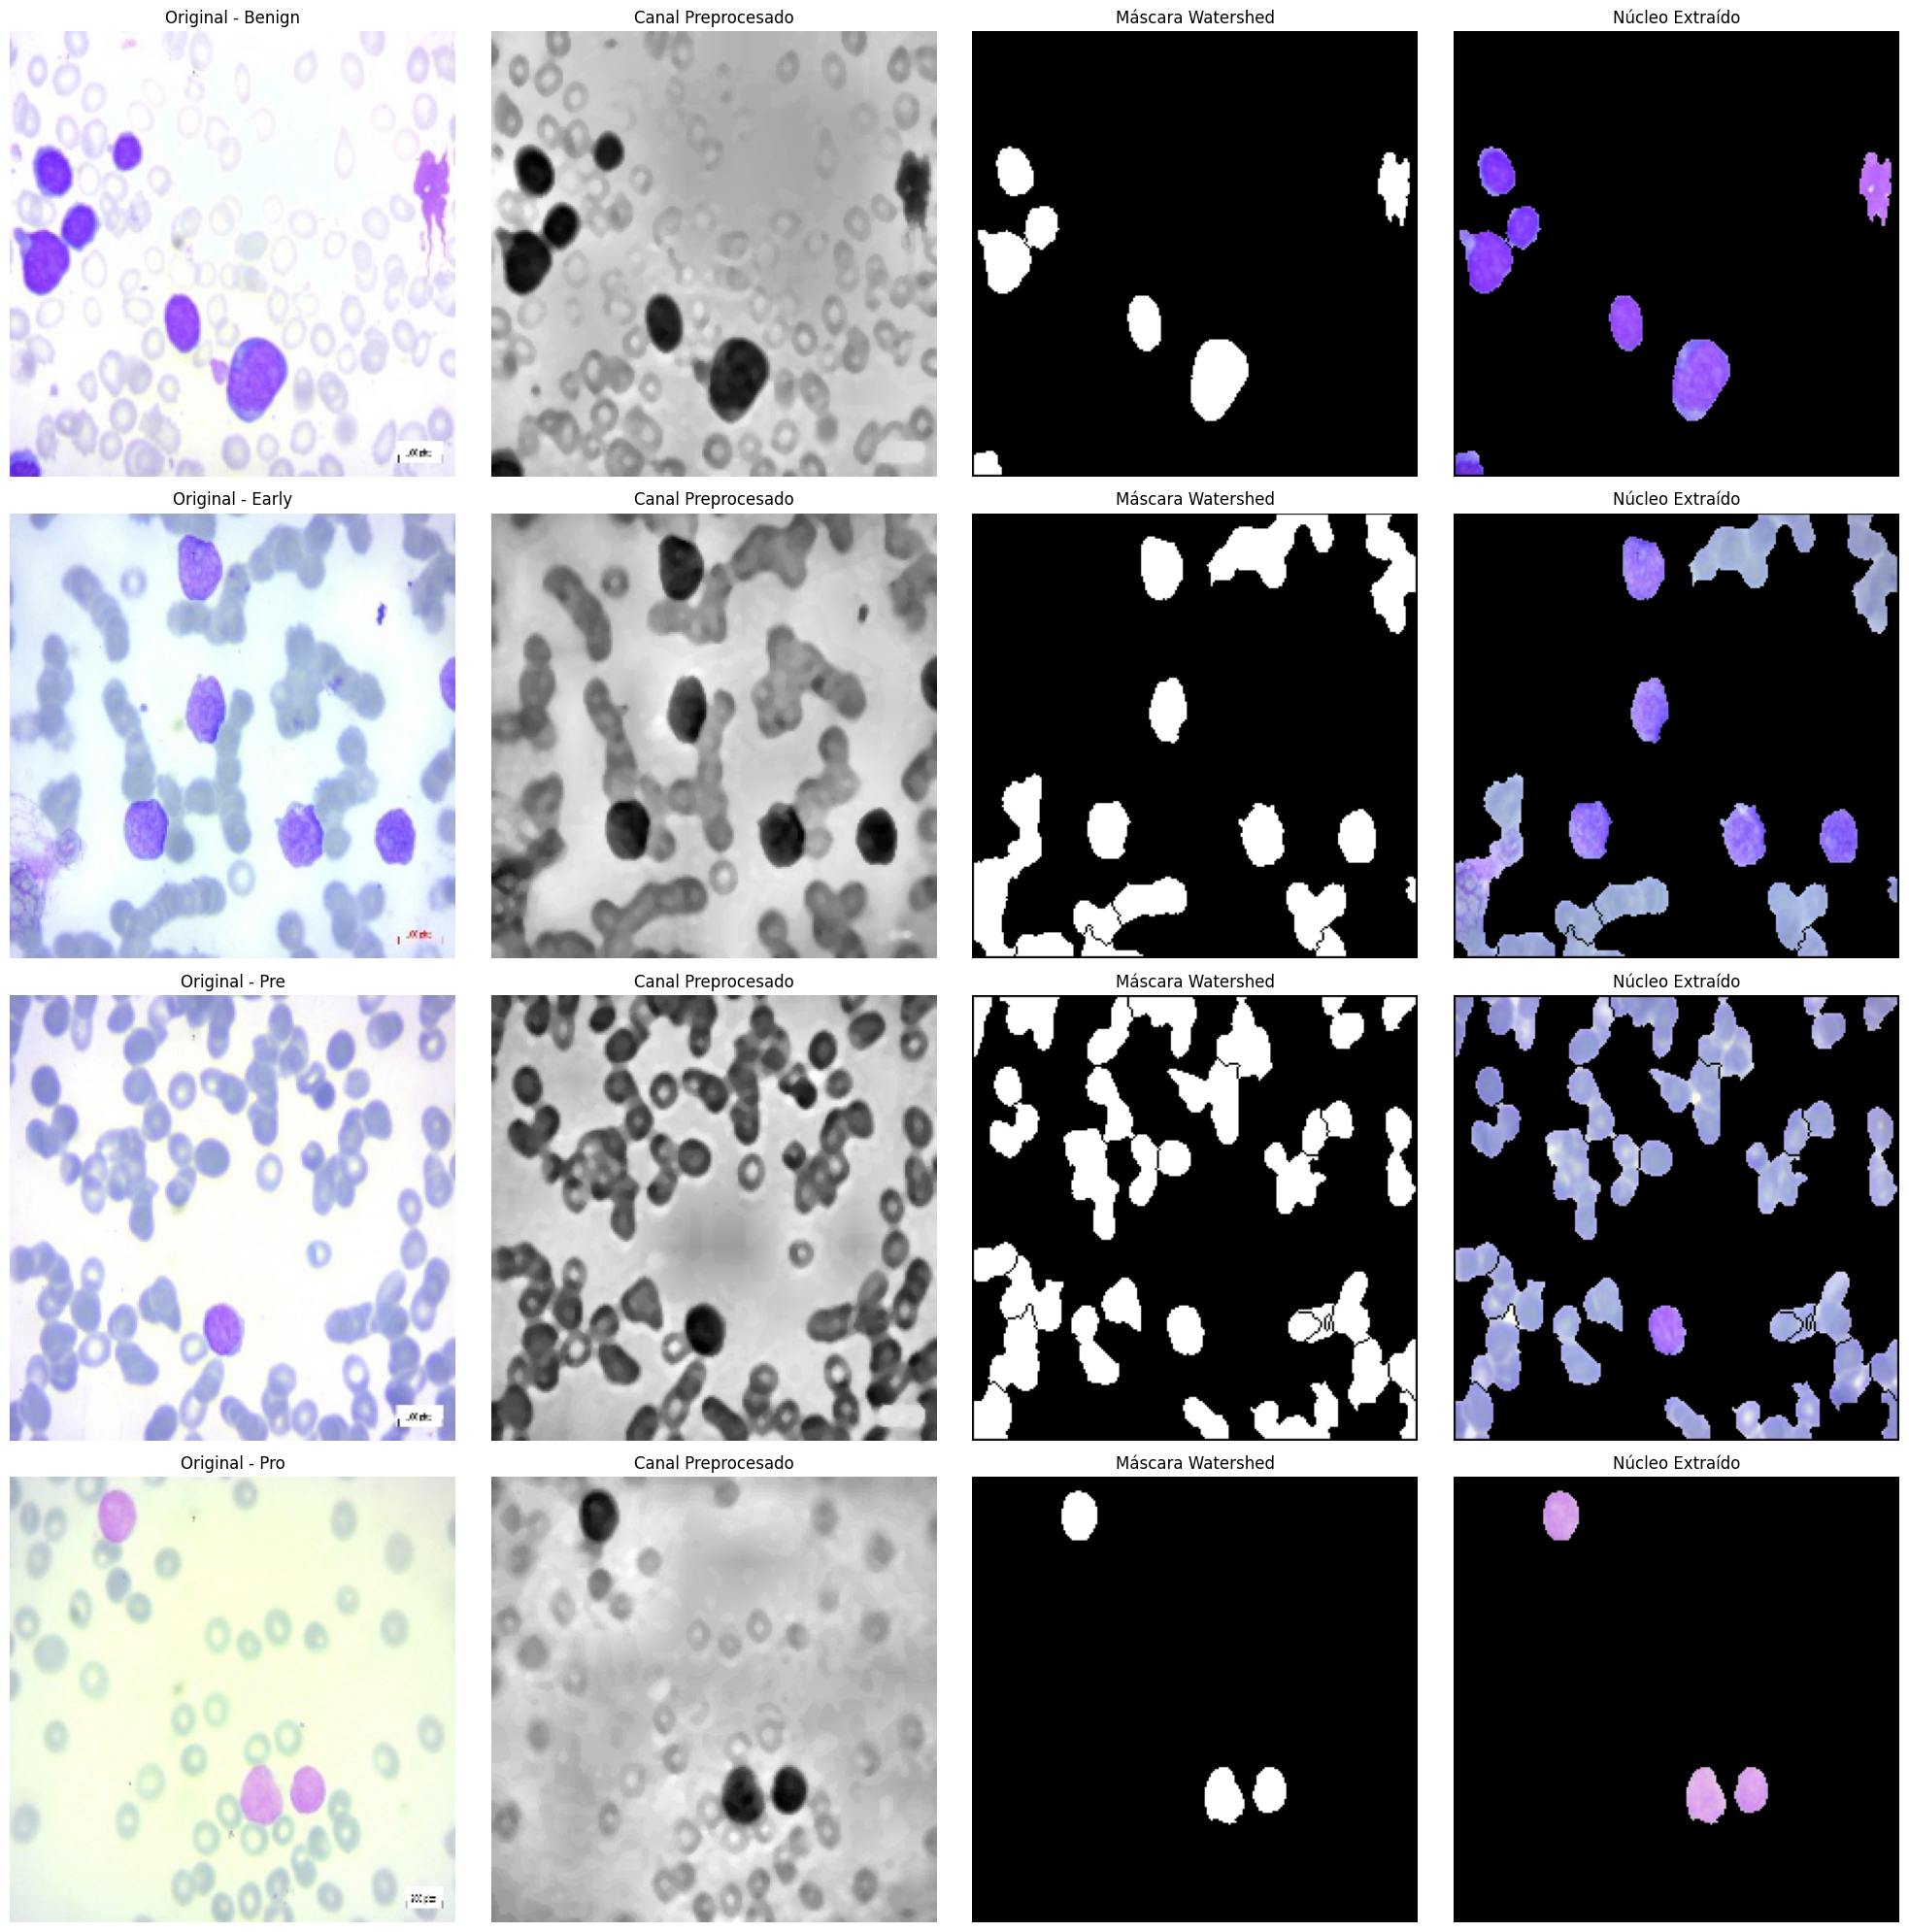

In [5]:
def extraer_region_color(img_rgb, mascara):
    """
    Toma la imagen original y la máscara binaria.
    Multiplica ambas para 'apagar' el fondo (negro) y dejar solo 
    la región de interés con sus colores originales.
    """
    # cv2.bitwise_and aplica una operación AND a nivel de bits.
    # Al pasarle la máscara, solo mantiene los píxeles donde la máscara es > 0.
    nucleo_extraido = cv2.bitwise_and(img_rgb, img_rgb, mask=mascara)
    
    return nucleo_extraido

# =========================================================
# VISUALIZACIÓN DEL PIPELINE COMPLETO HASTA AHORA
# =========================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for i, (clase, rutas) in enumerate(dataset.items()):
    if len(rutas) > 0:
        ruta_prueba = rutas[0]
        
        # 1. Preprocesamiento
        img_original, img_preprocesada = preprocesar_imagen(ruta_prueba)
        
        # 2. Segmentación (Usamos solo Watershed con tu factor de 0.52)
        _, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, fg_factor=0.52)
        
        # 3. Extracción del núcleo a color
        nucleo_color = extraer_region_color(img_original, mask_ws)
        
        # Col 0: Original
        axes[i, 0].imshow(img_original)
        axes[i, 0].set_title(f"Original - {clase}")
        axes[i, 0].axis("off")
        
        # Col 1: Preprocesada
        axes[i, 1].imshow(img_preprocesada, cmap="gray")
        axes[i, 1].set_title("Canal Preprocesado")
        axes[i, 1].axis("off")
        
        # Col 2: Máscara Watershed
        axes[i, 2].imshow(mask_ws, cmap="gray")
        axes[i, 2].set_title("Máscara Watershed")
        axes[i, 2].axis("off")
        
        # Col 3: Núcleo a color
        axes[i, 3].imshow(nucleo_color)
        axes[i, 3].set_title("Núcleo Extraído")
        axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

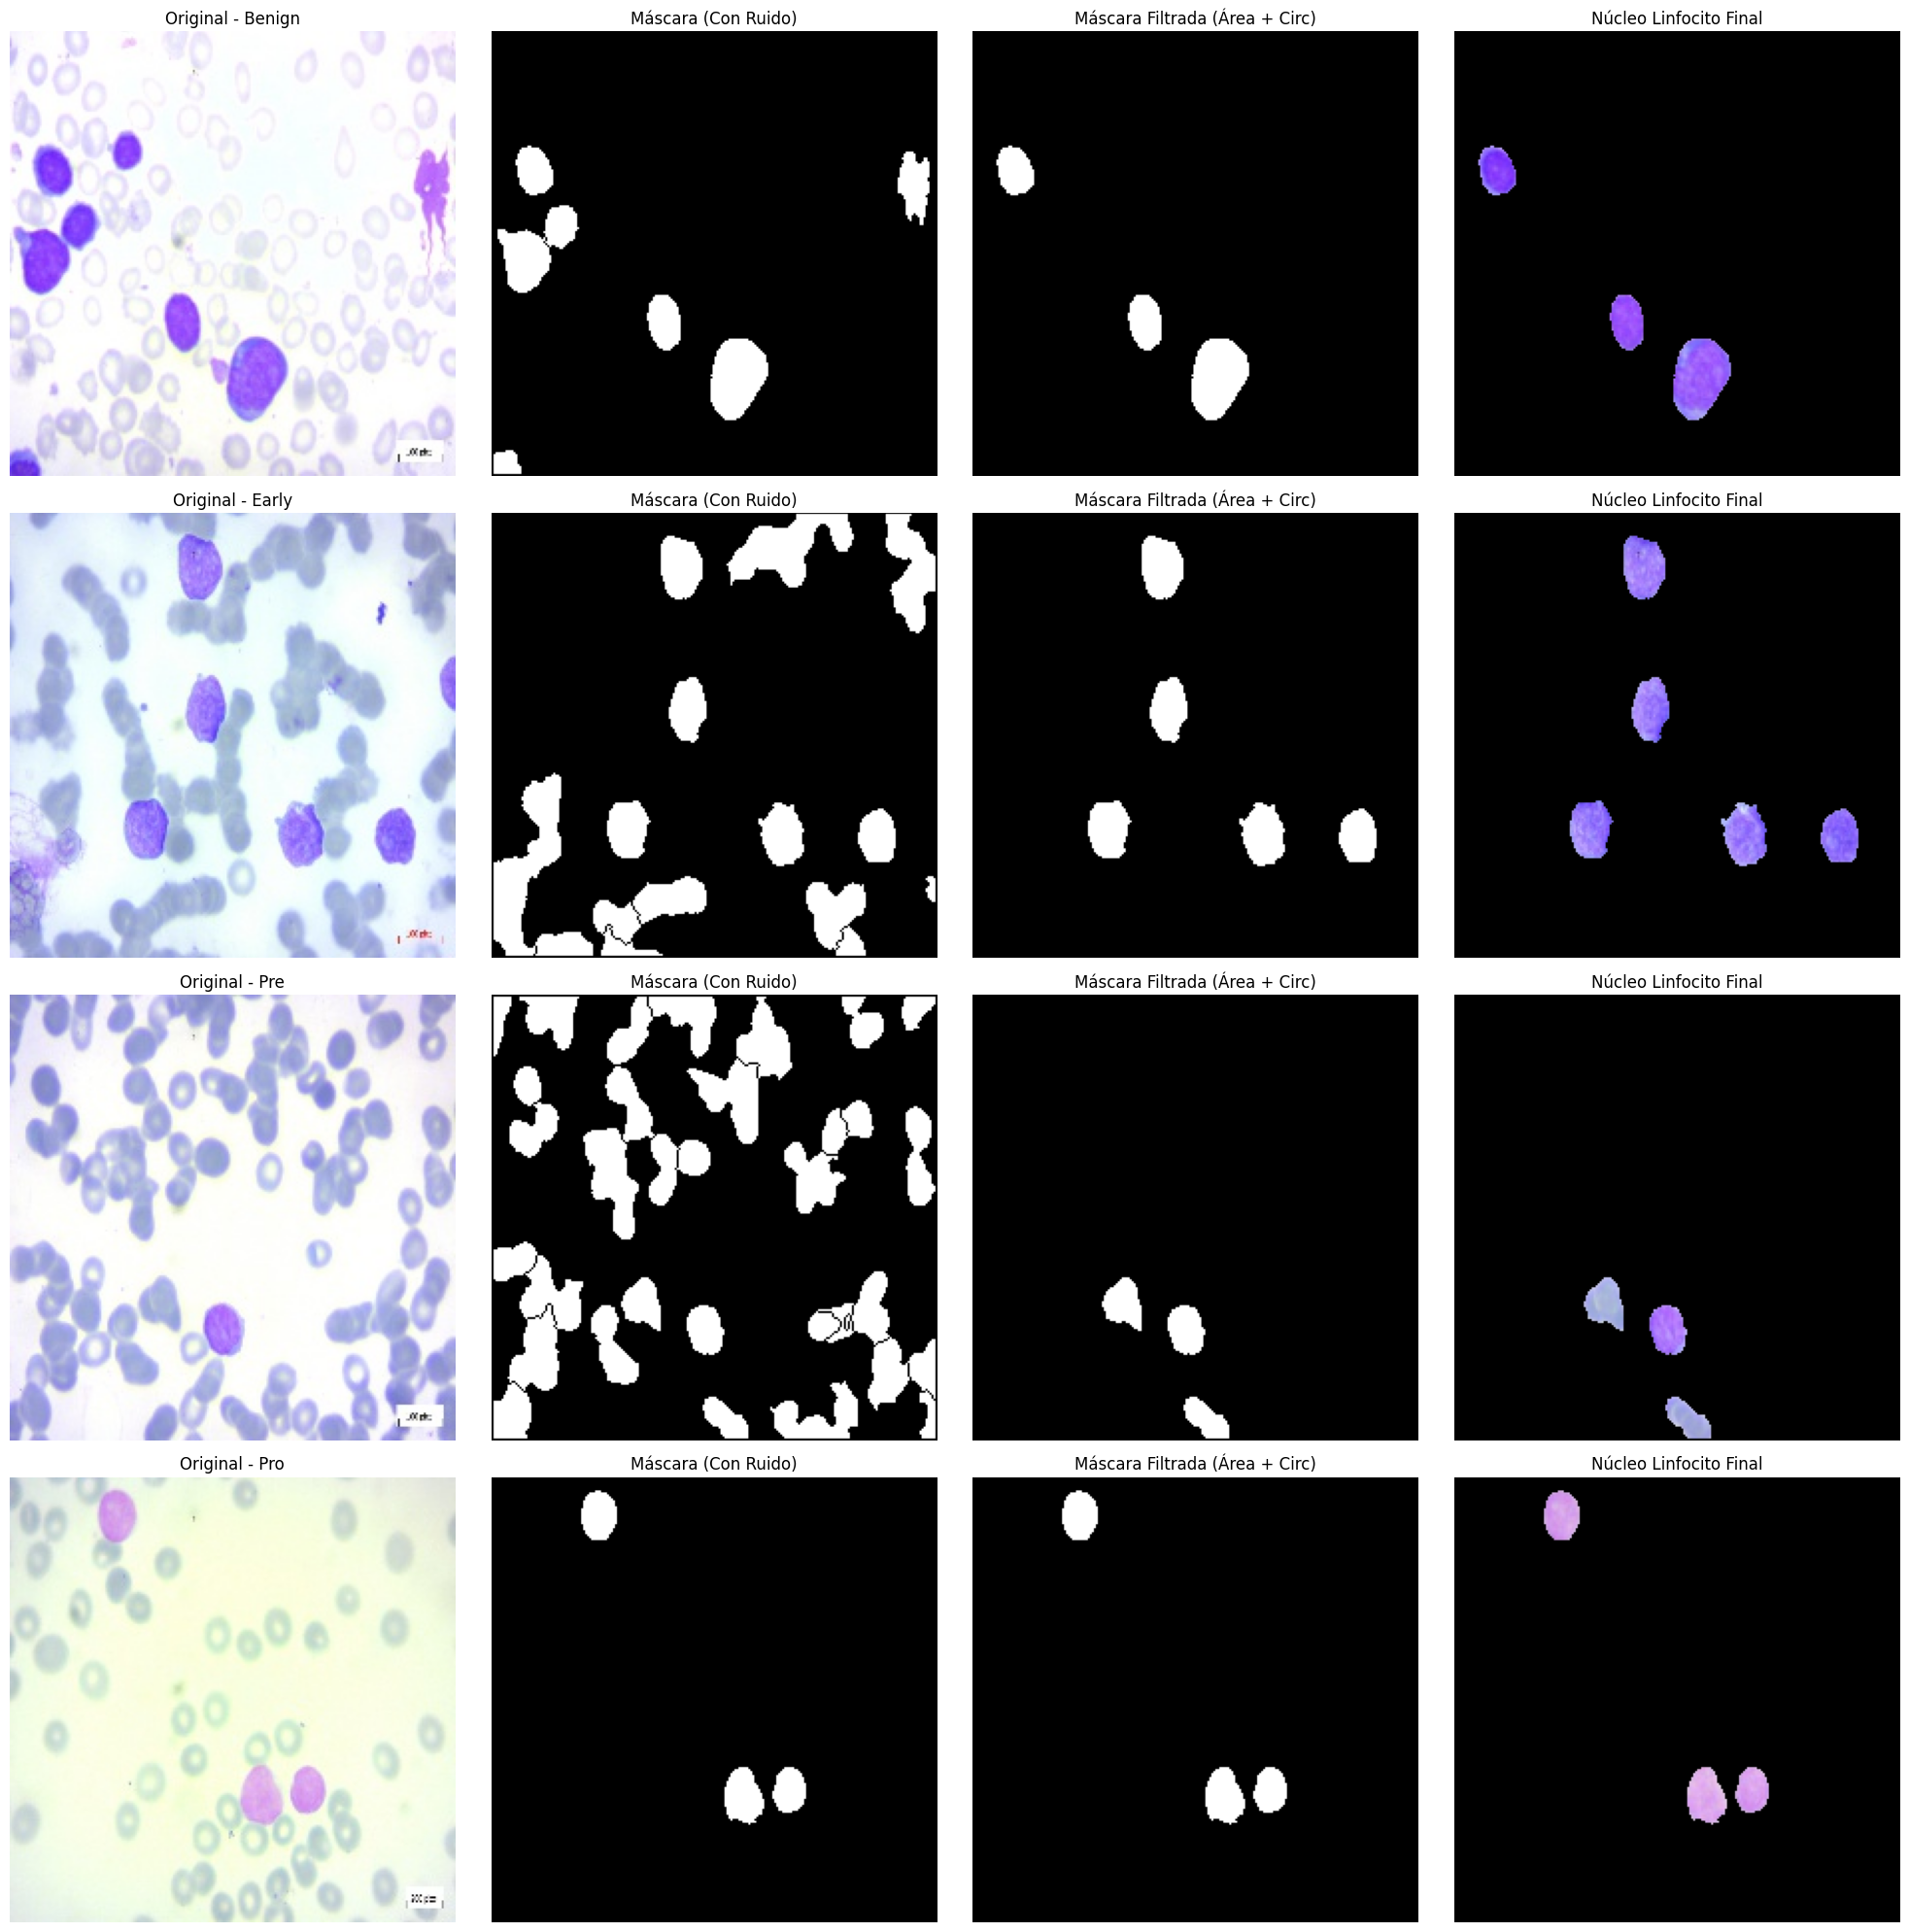

In [6]:
def filtrar_linfocitos(mascara, min_area=1000, min_circularidad=0.5):
    """
    Busca los contornos en la máscara y filtra aquellos que no cumplen
    con el tamaño o la forma típica de un núcleo de linfocito.
    """
    # Encontramos los contornos en la máscara de Watershed
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Creamos una máscara negra vacía para dibujar solo lo que pase el filtro
    mascara_filtrada = np.zeros_like(mascara)
    
    for c in contornos:
        area = cv2.contourArea(c)
        perimetro = cv2.arcLength(c, True)
        
        # Evitar división por cero
        if perimetro == 0:
            continue
            
        # Calculamos la circularidad
        circularidad = 4 * np.pi * (area / (perimetro * perimetro))
        
        # Filtramos por Área y Circularidad
        if area > min_area and circularidad > min_circularidad:
            # Si cumple las condiciones, lo dibujamos en blanco (255) en la nueva máscara
            # El -1 indica que rellene todo el contorno
            cv2.drawContours(mascara_filtrada, [c], -1, 255, -1)
            
    return mascara_filtrada


# =========================================================
# VISUALIZACIÓN: AGREGANDO EL FILTRO MORFOLÓGICO
# =========================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for i, (clase, rutas) in enumerate(dataset.items()):
    if len(rutas) > 0:
        ruta_prueba = rutas[0]
        
        # 1. Preprocesamiento
        img_original, img_preprocesada = preprocesar_imagen(ruta_prueba)
        
        # 2. Segmentación (Watershed)
        _, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, fg_factor=0.52)
        
        # 3. FILTRO MORFOLÓGICO (Nuevo paso)
        # Los valores min_area y min_circularidad se pueden ajustar empíricamente
        mask_filtrada = filtrar_linfocitos(mask_ws, min_area=200, min_circularidad=0.55)
        
        # 4. Extracción del núcleo a color usando la máscara limpia
        nucleo_color = extraer_region_color(img_original, mask_filtrada)
        
        # Col 0: Original
        axes[i, 0].imshow(img_original)
        axes[i, 0].set_title(f"Original - {clase}")
        axes[i, 0].axis("off")
        
        # Col 1: Máscara Watershed (Cruda)
        axes[i, 1].imshow(mask_ws, cmap="gray")
        axes[i, 1].set_title("Máscara (Con Ruido)")
        axes[i, 1].axis("off")
        
        # Col 2: Máscara Filtrada (Limpia)
        axes[i, 2].imshow(mask_filtrada, cmap="gray")
        axes[i, 2].set_title("Máscara Filtrada (Área + Circ)")
        axes[i, 2].axis("off")
        
        # Col 3: Núcleo a color
        axes[i, 3].imshow(nucleo_color)
        axes[i, 3].set_title("Núcleo Linfocito Final")
        axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

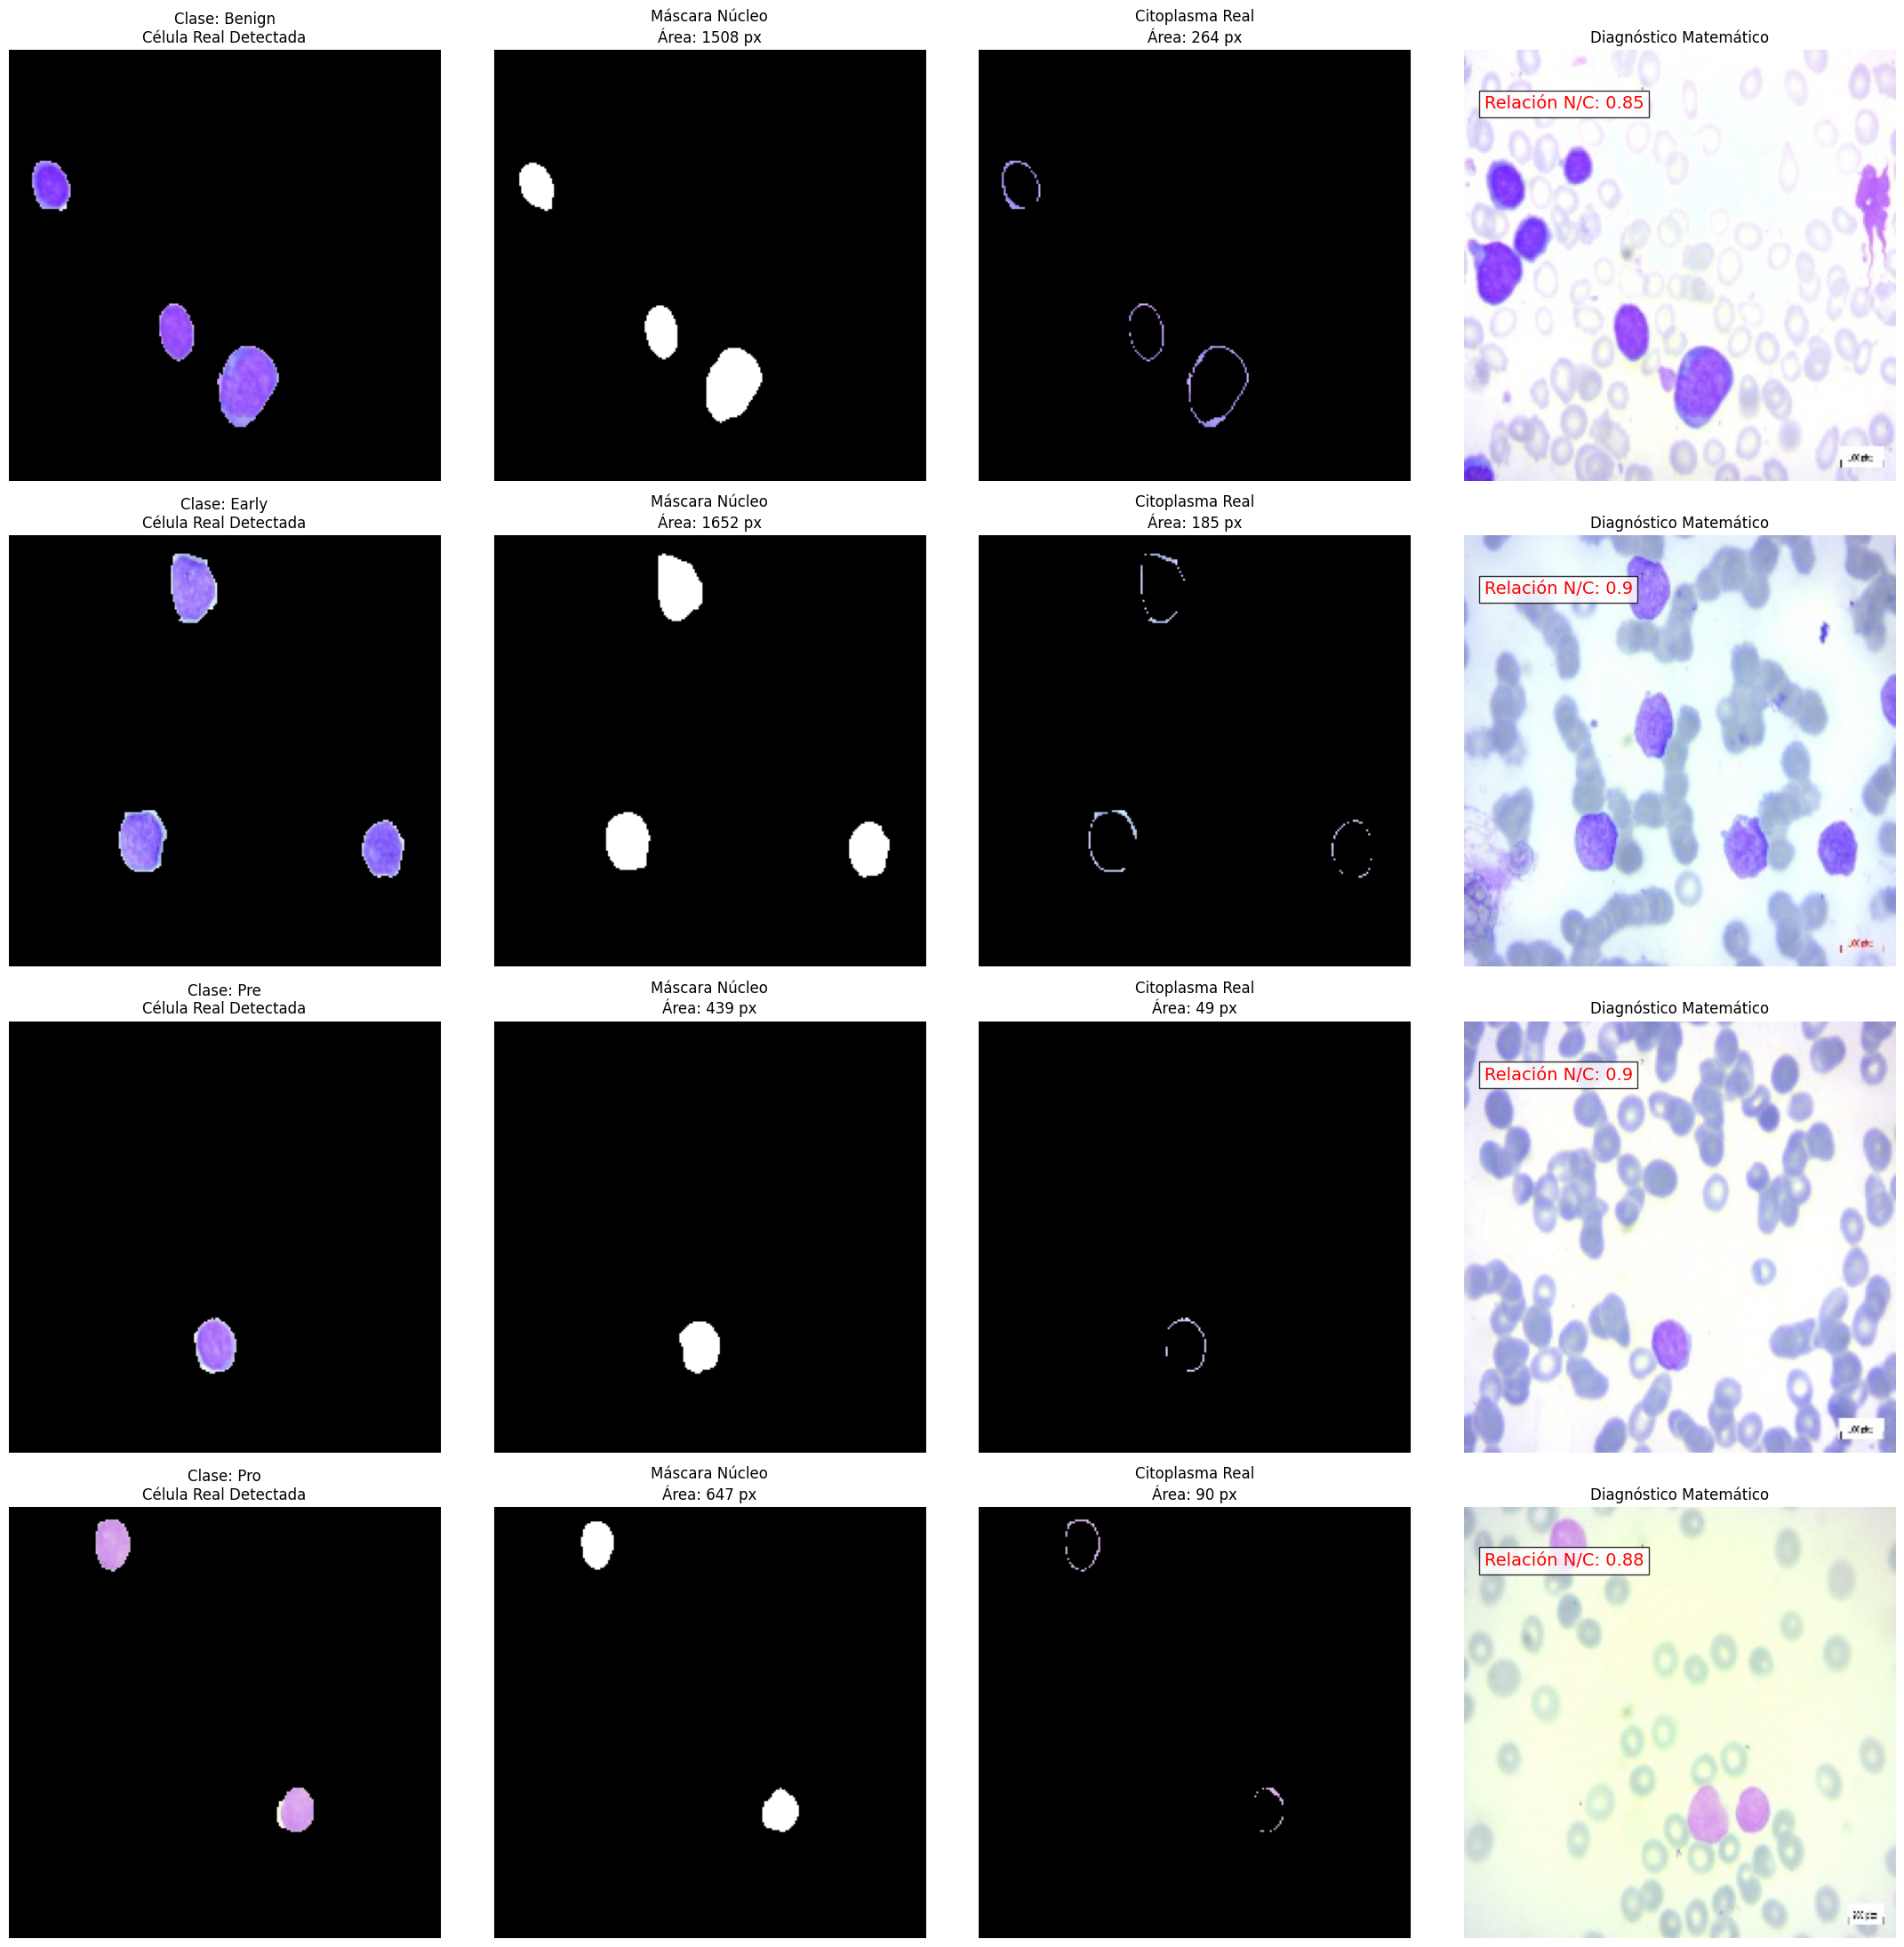

In [7]:
def expandir_mascara_celula(mascara_base, iteraciones=1):
    """
    Toma la máscara del linfocito ya filtrada y la dilata (expande) 
    artificialmente para asegurar que englobe todo el citoplasma.
    """
    kernel = np.ones((5,5), np.uint8)
    mascara_expandida = cv2.dilate(mascara_base, kernel, iterations=iteraciones)
    return mascara_expandida


def segmentar_nucleo_agresivo(canal_preprocesado, ajuste_otsu=-20):
    """
    Detecta el núcleo estrictamente por color oscuro (para salvar el citoplasma Benign), 
    pero aplica un pegamento morfológico elíptico para fusionar núcleos pálidos (Pro).
    """
    # 1. Umbral MUY estricto
    umbral_otsu, _ = cv2.threshold(canal_preprocesado, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    umbral_estricto = umbral_otsu + ajuste_otsu
    _, mask_nucleo = cv2.threshold(canal_preprocesado, umbral_estricto, 255, cv2.THRESH_BINARY_INV)
    
    # 2. Pegamento morfológico elíptico (Más orgánico que el cuadrado)
    kernel_cierre = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask_nucleo = cv2.morphologyEx(mask_nucleo, cv2.MORPH_CLOSE, kernel_cierre)
    
    # Pequeña limpieza de bordes
    kernel_apertura = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_nucleo = cv2.morphologyEx(mask_nucleo, cv2.MORPH_OPEN, kernel_apertura)
    
    # 3. Rellenado de contornos (Rellena la fase Pro si quedó hueca)
    contornos, _ = cv2.findContours(mask_nucleo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_rellena = np.zeros_like(mask_nucleo)
    
    for c in contornos:
        # Solo conservamos aglomeraciones grandes de núcleo (evita ruido)
        if cv2.contourArea(c) > 150:
            cv2.drawContours(mask_rellena, [c], -1, 255, -1)
            
    return mask_rellena

def aislar_citoplasma_real(img_rgb, mascara_expandida, mascara_nucleo):
    """
    Usa el canal de Saturación con un umbral relajado para atrapar 
    el citoplasma pálido de las células benignas.
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    _, s, _ = cv2.split(hsv)
    
    # 1. Otsu sobre la saturación, pero le restamos 15 puntos para ser permisivos
    umbral_otsu, _ = cv2.threshold(s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    umbral_relajado = max(0, umbral_otsu - 15)  # Evitamos que baje de 0
    _, mascara_materia = cv2.threshold(s, umbral_relajado, 255, cv2.THRESH_BINARY)
    
    # 2. Intersección
    celula_real = cv2.bitwise_and(mascara_materia, mascara_expandida)
    
    # 3. FILTRO TOPOLÓGICO (Fusión y Limpieza)
    contornos, _ = cv2.findContours(celula_real, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    celula_limpia = np.zeros_like(celula_real)
    
    for c in contornos:
        temp_mask = np.zeros_like(celula_real)
        cv2.drawContours(temp_mask, [c], -1, 255, -1)
        
        superposicion = cv2.bitwise_and(temp_mask, mascara_nucleo)
        
        if cv2.countNonZero(superposicion) > 0:
            cv2.drawContours(celula_limpia, [c], -1, 255, -1)
            
    # 4. Restamos el núcleo
    citoplasma_final = cv2.subtract(celula_limpia, mascara_nucleo)
    
    return citoplasma_final

# =========================================================
# VISUALIZACIÓN: RELACIÓN N/C (Restaurada y Mejorada)
# =========================================================
fig, axes = plt.subplots(4, 4, figsize=(22, 22))

for i, (clase, rutas) in enumerate(dataset.items()):
    if len(rutas) > 0:
        ruta_prueba = rutas[0]
        
        # 1. Preprocesamiento
        img_original, img_preprocesada = preprocesar_imagen(ruta_prueba)
        
        # 2. Máscara Base (Watershed + Filtro) -> Ancla
        _, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, fg_factor=0.52)
        mask_base = filtrar_linfocitos(mask_ws, min_area=200, min_circularidad=0.75)
        
        # 3. EXPANSIÓN (Zona de búsqueda)
        mask_zona_busqueda = expandir_mascara_celula(mask_base, iteraciones=1)
        
        # 4. NÚCLEO AGRESIVO + RELLENO (La clave para la fase Pro)
        mask_nucleo_bruto = segmentar_nucleo_agresivo(img_preprocesada, ajuste_otsu=-20)
        mask_nucleo_final = cv2.bitwise_and(mask_nucleo_bruto, mask_zona_busqueda)
        
        # 5. CITOPLASMA REAL Y ÁREAS
        mask_citoplasma = aislar_citoplasma_real(img_original, mask_zona_busqueda, mask_nucleo_final)
        
        area_nucleo = cv2.countNonZero(mask_nucleo_final)
        area_citoplasma = cv2.countNonZero(mask_citoplasma)
        
        # Tu excelente corrección matemática
        area_total = area_citoplasma + area_nucleo
        if area_total == 0:
            relacion_nc = 0
        else:
            relacion_nc = round(area_nucleo / area_total, 2)
        
        # --- GRAFICACIÓN ---
        # Col 0: Célula Real Detectada
        mask_celula_limpia = cv2.bitwise_or(mask_nucleo_final, mask_citoplasma)
        celula_color = extraer_region_color(img_original, mask_celula_limpia)
        axes[i, 0].imshow(celula_color)
        axes[i, 0].set_title(f"Clase: {clase}\nCélula Real Detectada")
        axes[i, 0].axis("off")
        
        # Col 1: Máscara Núcleo Agresivo
        axes[i, 1].imshow(mask_nucleo_final, cmap="gray")
        axes[i, 1].set_title(f"Máscara Núcleo\nÁrea: {area_nucleo} px")
        axes[i, 1].axis("off")
        
        # Col 2: Citoplasma Real
        citoplasma_color = extraer_region_color(img_original, mask_citoplasma)
        axes[i, 2].imshow(citoplasma_color)
        axes[i, 2].set_title(f"Citoplasma Real\nÁrea: {area_citoplasma} px")
        axes[i, 2].axis("off")
        
        # Col 3: Resultado de la Relación N/C
        axes[i, 3].imshow(img_original)
        texto_diagnostico = f"Relación N/C: {relacion_nc}"
        axes[i, 3].text(10, 30, texto_diagnostico, color='red', fontsize=14, 
                        bbox=dict(facecolor='white', alpha=0.8))
        axes[i, 3].set_title("Diagnóstico Matemático")
        axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

In [8]:
def es_celula_rosada(img_rgb, mascara_celula, umbral_porcentaje=0.15):
    """
    Detecta si una porción significativa de la célula tiene coloración rosada/magenta.
    Ideal para identificar prolinfoblastos.
    """
    # Convertimos a HSV
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    
    # Rango de colores rosados/magenta en OpenCV (Hue entre 130 y 175)
    # Saturation baja/media (20-255) y Value (Brillo) medio/alto (50-255)
    rango_bajo = np.array([130, 20, 50])
    rango_alto = np.array([175, 255, 255])
    
    # Máscara de los píxeles que caen en ese rango de color
    mask_color_rosado = cv2.inRange(hsv, rango_bajo, rango_alto)
    
    # Nos quedamos solo con los píxeles rosados que están DENTRO de nuestra célula
    rosado_en_celula = cv2.bitwise_and(mask_color_rosado, mascara_celula)
    
    pixeles_rosados = cv2.countNonZero(rosado_en_celula)
    pixeles_totales = cv2.countNonZero(mascara_celula)
    
    if pixeles_totales == 0:
        return False
        
    porcentaje_rosado = pixeles_rosados / pixeles_totales
    
    # Devuelve True si el porcentaje supera el umbral
    return porcentaje_rosado > umbral_porcentaje

In [9]:
def es_nucleo_rosado(img_rgb, mascara_nucleo, umbral_porcentaje=0.25):
    """
    Detecta si una porción significativa del NÚCLEO tiene coloración rosada/laxa.
    Los núcleos benignos son morados oscuros y fallarán esta prueba.
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    
    # Ajustamos la saturación mínima a 30 para no agarrar blancos puros/grises
    rango_bajo = np.array([125, 30, 50])
    rango_alto = np.array([175, 255, 255])
    
    mask_color_rosado = cv2.inRange(hsv, rango_bajo, rango_alto)
    
    # Nos quedamos solo con los píxeles rosados que están DENTRO del NÚCLEO
    rosado_en_nucleo = cv2.bitwise_and(mask_color_rosado, mascara_nucleo)
    
    pixeles_rosados = cv2.countNonZero(rosado_en_nucleo)
    pixeles_totales = cv2.countNonZero(mascara_nucleo)
    
    if pixeles_totales == 0:
        return False
        
    porcentaje_rosado = pixeles_rosados / pixeles_totales
    
    # Devuelve True si el rosado supera el 25% del núcleo
    return porcentaje_rosado > umbral_porcentaje

In [10]:
def calcular_porcentaje_rosado_total(img_rgb, mask_celula):
    """Calcula el porcentaje de tonos rosados en toda la célula sin umbrales rígidos."""
    if cv2.countNonZero(mask_celula) == 0:
        return 0.0
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    # Rango amplio de tonos rosados/magentas/pálidos del frotis
    rango_bajo = np.array([125, 20, 40])
    rango_alto = np.array([175, 255, 255])
    mask_rosado = cv2.inRange(hsv, rango_bajo, rango_alto)
    rosado_celula = cv2.bitwise_and(mask_rosado, mask_celula)
    return round(cv2.countNonZero(rosado_celula) / cv2.countNonZero(mask_celula), 4)

In [11]:

# Lista para acumular los datos de cada célula
datos_extraccion = []

print("Extrayendo características reales de todo el dataset...")

for clase, rutas in dataset.items():
    for i, ruta in enumerate(rutas):
        try:
            # 1. Preprocesamiento
            img_original, img_preprocesada = preprocesar_imagen(ruta)
            
            # 2. Máscara Base (Watershed)
            _, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, fg_factor=0.52)
            mask_base = filtrar_linfocitos(mask_ws, min_area=200, min_circularidad=0.75)
            
            # 3. Zona de búsqueda
            mask_zona_busqueda = expandir_mascara_celula(mask_base, iteraciones=1)
            
            # 4. Núcleo (Uso un Otsu estándar equilibrado, sin extremos)
            mask_nucleo_bruto = segmentar_nucleo_agresivo(img_preprocesada, ajuste_otsu=-10)
            mask_nucleo_final = cv2.bitwise_and(mask_nucleo_bruto, mask_zona_busqueda)
            
            # 5. Citoplasma
            mask_citoplasma = aislar_citoplasma_real(img_original, mask_zona_busqueda, mask_nucleo_final)
            
            # Cantidad de píxeles
            area_nucleo = cv2.countNonZero(mask_nucleo_final)
            area_citoplasma = cv2.countNonZero(mask_citoplasma)
            area_total = area_nucleo + area_citoplasma
            
            if area_total > 0:
                relacion_nc = area_nucleo / area_total
                mask_celula_completa = cv2.bitwise_or(mask_nucleo_final, mask_citoplasma)
                porcentaje_rosado = calcular_porcentaje_rosado_total(img_original, mask_celula_completa)
                
                # Guardamos los datos crudos
                datos_extraccion.append({
                    "Clase": clase,
                    "Area_Nucleo": area_nucleo,
                    "Area_Citoplasma": area_citoplasma,
                    "Relacion_NC": round(relacion_nc, 4),
                    "Porcentaje_Rosado": porcentaje_rosado
                })
        except Exception as e:
            # Si alguna imagen falla o está corrupta, la salteamos silenciosamente
            continue

# Convertimos a un DataFrame de Pandas
df_caracteristicas = pd.DataFrame(datos_extraccion)

# =========================================================
# REPORTE DE MEDIAS REALES POR CARPETA
# =========================================================
print("\n=== ANÁLISIS DE DATOS REALES (PROMEDIOS POR CLASE) ===")
reporte_promedios = df_caracteristicas.groupby("Clase").mean()
print(reporte_promedios)

Extrayendo características reales de todo el dataset...

=== ANÁLISIS DE DATOS REALES (PROMEDIOS POR CLASE) ===
        Area_Nucleo  Area_Citoplasma  Relacion_NC  Porcentaje_Rosado
Clase                                                               
Benign  1145.011765        71.297059     0.942672           0.562666
Early   1361.169089        58.501982     0.962449           0.562045
Pre     2448.334917        70.794537     0.970582           0.320628
Pro     1126.076023       101.777778     0.917645           0.718395


In [12]:

def calcular_porcentaje_rosado_total(img_rgb, mask_celula):
    if cv2.countNonZero(mask_celula) == 0: return 0.0
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    rango_bajo = np.array([125, 20, 40])
    rango_alto = np.array([175, 255, 255])
    mask_rosado = cv2.inRange(hsv, rango_bajo, rango_alto)
    rosado_celula = cv2.bitwise_and(mask_rosado, mask_celula)
    return round(cv2.countNonZero(rosado_celula) / cv2.countNonZero(mask_celula), 4)

Extrayendo características geométricas y de textura avanzadas...

Clasificando células mediante el sistema experto de reglas ópticas (SIN ML)...

=== REPORTE DE RENDIMIENTO ALGORÍTMICO (REGLAS RÍGIDAS) ===
              precision    recall  f1-score   support

      Benign       0.11      0.03      0.04       340
       Early       0.10      0.02      0.04       757
         Pre       0.00      0.00      0.00       842
         Pro       0.28      0.96      0.43       684

    accuracy                           0.26      2623
   macro avg       0.12      0.25      0.13      2623
weighted avg       0.11      0.26      0.13      2623



c:\Users\matia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\matia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\matia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

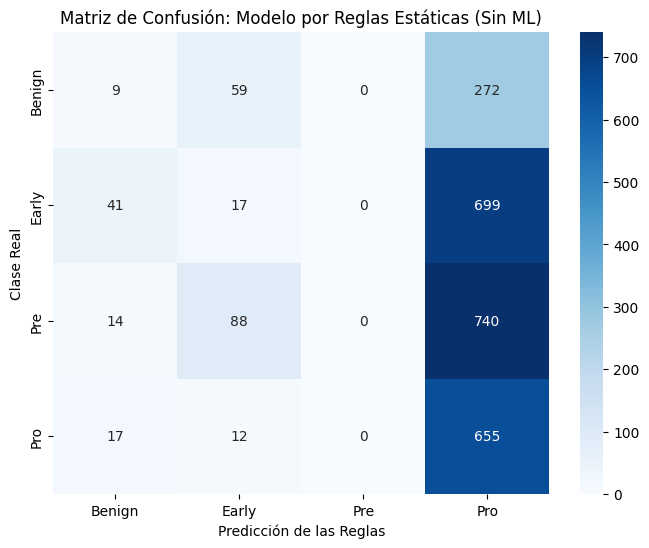

In [13]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. FUNCIÓN DE CLASIFICACIÓN POR REGLAS (SIN MACHINE LEARNING)
# ==============================================================================
def clasificar_celula_por_reglas(row):
    """
    Clasifica la célula usando umbrales fijos sobre las características extraídas.
    """
    rosado       = row['Porcentaje_Rosado']
    rugosidad    = row['Rugosidad_Nucleo']
    relacion_nc  = row['Relacion_NC']
    area_nucleo  = row['Area_Nucleo']
    
    # REGLA 1: La clase Pro es la única con un tono rosado muy fuerte.
    if rosado > 0.08:  
        return 'Pro'
    
    # REGLA 2: Las células sanas (Benign) tienen un núcleo liso y sin parches (rugosidad baja)
    elif rugosidad < 15.5:
        # Mini-filtro por si un blasto Early es liso pero enorme
        if relacion_nc > 0.85 and area_nucleo > 12000:
            return 'Early'
        return 'Benign'
    
    # REGLA 3: Desempate por tamaño para Early y Pre
    elif relacion_nc > 0.85 or area_nucleo > 15000:
        return 'Early'
    else:
        return 'Pre'

# ==============================================================================
# 2. EXTRACCIÓN DE CARACTERÍSTICAS (Tu código original intacto)
# ==============================================================================
datos_avanzados = []
print("Extrayendo características geométricas y de textura avanzadas...")

for clase, rutas in dataset.items():
    for ruta in rutas:
        try:
            img_original, img_preprocesada = preprocesar_imagen(ruta)
            _, mask_ws = segmentar_otsu_vs_watershed(img_original, img_preprocesada, fg_factor=0.52)
            mask_base = filtrar_linfocitos(mask_ws, min_area=200, min_circularidad=0.75)
            mask_zona_busqueda = expandir_mascara_celula(mask_base, iteraciones=1)
            mask_nucleo_bruto = segmentar_nucleo_agresivo(img_preprocesada, ajuste_otsu=-10)
            mask_nucleo_final = cv2.bitwise_and(mask_nucleo_bruto, mask_zona_busqueda)
            mask_citoplasma = aislar_citoplasma_real(img_original, mask_zona_busqueda, mask_nucleo_final)
            
            area_nucleo = cv2.countNonZero(mask_nucleo_final)
            area_citoplasma = cv2.countNonZero(mask_citoplasma)
            area_total = area_nucleo + area_citoplasma
            
            if area_total > 0 and area_nucleo > 0:
                relacion_nc = area_nucleo / area_total
                mask_celula_completa = cv2.bitwise_or(mask_nucleo_final, mask_citoplasma)
                porcentaje_rosado = calcular_porcentaje_rosado_total(img_original, mask_celula_completa)
                
                # --- NUEVAS CARACTERÍSTICAS GEOMÉTRICAS ---
                contornos, _ = cv2.findContours(mask_nucleo_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if len(contornos) > 0:
                    c = max(contornos, key=cv2.contourArea)
                    perimetro = cv2.arcLength(c, True)
                    circularidad = (4 * np.pi * area_nucleo) / (perimetro ** 2) if perimetro > 0 else 0
                    x, y, w, h = cv2.boundingRect(c)
                    aspect_ratio = float(w) / h if h > 0 else 0
                else:
                    circularidad, aspect_ratio = 1.0, 1.0
                
                # --- NUEVAS CARACTERÍSTICAS DE TEXTURA (GRISES) ---
                pixeles_nucleo = img_preprocesada[mask_nucleo_final > 0]
                desviacion_textura = np.std(pixeles_nucleo) if len(pixeles_nucleo) > 0 else 0.0
                
                datos_avanzados.append({
                    "Clase": clase,
                    "Area_Nucleo": area_nucleo,
                    "Area_Citoplasma": area_citoplasma,
                    "Relacion_NC": round(relacion_nc, 4),
                    "Porcentaje_Rosado": porcentaje_rosado,
                    "Circularidad_Nucleo": round(circularidad, 4),
                    "Aspect_Ratio": round(aspect_ratio, 4),
                    "Rugosidad_Nucleo": round(desviacion_textura, 4)
                })
        except:
            continue

# ==============================================================================
# 3. CREACIÓN DEL DATAFRAME Y APLICACIÓN DE LAS REGLAS
# ==============================================================================
df_robusto = pd.DataFrame(datos_avanzados)

print("\nClasificando células mediante el sistema experto de reglas ópticas (SIN ML)...")
# Le pasamos a cada fila la función de los IF que armamos arriba
df_robusto['Prediccion'] = df_robusto.apply(clasificar_celula_por_reglas, axis=1)

# ==============================================================================
# 4. REPORTE DE RENDIMIENTO CLÁSICO
# ==============================================================================
y_real = df_robusto["Clase"]
y_pred = df_robusto["Prediccion"]

print("\n=== REPORTE DE RENDIMIENTO ALGORÍTMICO (REGLAS RÍGIDAS) ===")
print(classification_report(y_real, y_pred))

# Matriz de confusión final en tonos azules
etiquetas = ['Benign', 'Early', 'Pre', 'Pro']
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_real, y_pred, labels=etiquetas)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas)
plt.title("Matriz de Confusión: Modelo por Reglas Estáticas (Sin ML)")
plt.ylabel("Clase Real")
plt.xlabel("Predicción de las Reglas")
plt.show()


Clasificando células mediante Sistema Experto Universal (Independiente de la escala)...

=== REPORTE DE RENDIMIENTO: SISTEMA UNIVERSAL (SIN ML) ===
              precision    recall  f1-score   support

      Benign       0.23      0.20      0.22       340
       Early       0.42      0.12      0.19       757
         Pre       0.78      0.72      0.75       842
         Pro       0.41      0.79      0.54       684

    accuracy                           0.50      2623
   macro avg       0.46      0.46      0.42      2623
weighted avg       0.51      0.50      0.46      2623



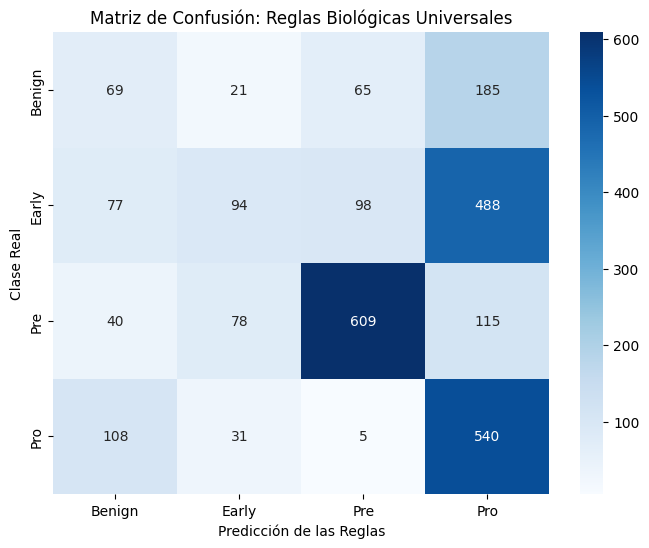

In [16]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. FUNCIÓN DE CLASIFICACIÓN UNIVERSAL (REGLAS BIOLÓGICAS RELATIVAS)
# ==============================================================================
def clasificar_celula_universal(row):
    """
    Clasificador experto diseñado para funcionar en cualquier imagen de frotis,
    utilizando únicamente proporciones y métricas relativas (independientes de 
    la resolución de la cámara).
    """
    rosado       = row['Porcentaje_Rosado']
    rugosidad    = row['Rugosidad_Nucleo']
    relacion_nc  = row['Relacion_NC']
    circularidad = row['Circularidad_Nucleo']
    
    # REGLA 1: MARCADOR PROLINFOBLÁSTICO (Cromatina laxa)
    # Los prolinfoblastos (Pro) son los únicos que presentan una tinción laxa tan 
    # evidente que más de la mitad de su superficie se ve rosada/pálida.
    if rosado > 0.55:
        return 'Pro'
    
    # REGLA 2: MARCADOR DE CÉLULA SANA (Cromatina densa y forma regular)
    # Los linfocitos maduros sanos (Benign) tienen la cromatina muy compacta (baja
    # variación de grises/rugosidad) y suelen conservar una forma bastante circular.
    elif rugosidad < 22.5 and circularidad > 0.70:
        return 'Benign'
    
    # REGLA 3: DIFERENCIACIÓN DE BLASTOS (Early vs Pre)
    # Llegados a este punto, la célula está enferma (alta rugosidad). 
    # En la leucemia, a medida que el blasto avanza (Pre), el núcleo hipertrofiado 
    # aplasta al citoplasma llevando la relación N/C a niveles extremos.
    elif relacion_nc > 0.95:
        return 'Pre'
    
    # REGLA 4: Si es un blasto pero aún conserva un mínimo margen citoplasmático.
    else:
        return 'Early'

# ==============================================================================
# 2. APLICACIÓN DE LAS REGLAS Y REPORTE
# ==============================================================================
# Asumiendo que tu DataFrame 'df_robusto' ya está cargado con los datos extraídos
print("\nClasificando células mediante Sistema Experto Universal (Independiente de la escala)...")
df_robusto['Prediccion'] = df_robusto.apply(clasificar_celula_universal, axis=1)

y_real = df_robusto["Clase"]
y_pred = df_robusto["Prediccion"]

print("\n=== REPORTE DE RENDIMIENTO: SISTEMA UNIVERSAL (SIN ML) ===")
print(classification_report(y_real, y_pred))

# Matriz de confusión final
etiquetas = ['Benign', 'Early', 'Pre', 'Pro']
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_real, y_pred, labels=etiquetas)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas)
plt.title("Matriz de Confusión: Reglas Biológicas Universales")
plt.ylabel("Clase Real")
plt.xlabel("Predicción de las Reglas")
plt.show()


Clasificando células mediante Sistema Experto V3 (Filtros Blindados)...

=== REPORTE DE RENDIMIENTO: SISTEMA BLINDADO V3 (SIN ML) ===
              precision    recall  f1-score   support

      Benign       0.06      0.02      0.03       340
       Early       0.59      0.12      0.19       757
         Pre       0.60      0.85      0.71       842
         Pro       0.44      0.74      0.55       684

    accuracy                           0.50      2623
   macro avg       0.42      0.43      0.37      2623
weighted avg       0.49      0.50      0.43      2623



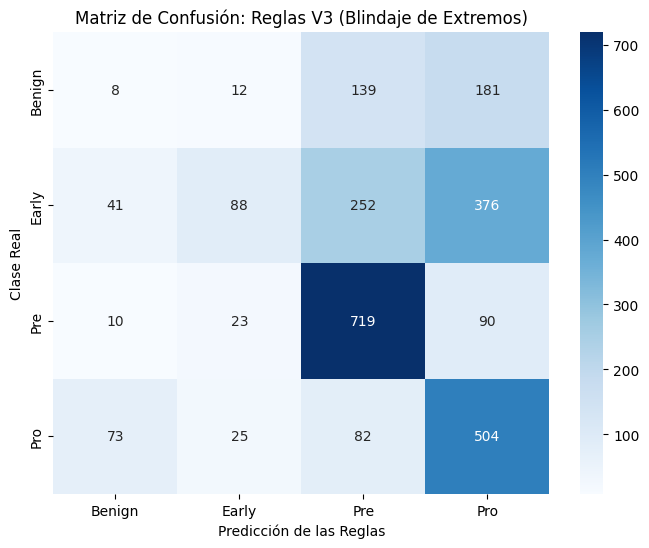

In [18]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. FUNCIÓN DE CLASIFICACIÓN V3 (BLINDAJE DE EXTREMOS)
# ==============================================================================
def clasificar_celula_v3_blindada(row):
    """
    Clasificador enfocado en proteger las métricas altas de Pro y Pre, 
    y usar un desempate estricto combinado para Benign y Early.
    """
    rosado       = row['Porcentaje_Rosado']
    rugosidad    = row['Rugosidad_Nucleo']
    relacion_nc  = row['Relacion_NC']
    
    # REGLA 1: BLINDAJE DE CLASE 'PRO'
    # Recuperamos el umbral que funcionaba bien para atrapar la mayoría sin robar de más.
    if rosado > 0.62:
        return 'Pro'
    
    # REGLA 2: BLINDAJE DE CLASE 'PRE'
    # Sabemos que son los más caóticos (rugosos) y los menos teñidos. 
    # Atrapamos por cualquiera de los dos extremos.
    elif rugosidad > 27.5 or rosado < 0.40:
        return 'Pre'
    
    # REGLA 3: DESEMPATE COMBINADO (BENIGN vs EARLY)
    # Llegamos acá con células de características "medias". 
    # Benign promedio: Rugosidad ~22.5, N/C ~0.94
    # Early promedio: Rugosidad ~25.4, N/C ~0.96
    # Exigimos que cumpla AMBAS condiciones de sanidad para ser Benigno.
    elif rugosidad < 24.0 and relacion_nc < 0.955:
        return 'Benign'
    
    # REGLA 4: EL RESTO ES 'EARLY'
    # Si no es muy rosado, ni muy rugoso, pero tampoco es lo suficientemente liso/sano.
    else:
        return 'Early'

# ==============================================================================
# 2. APLICACIÓN DE LAS REGLAS Y REPORTE
# ==============================================================================
print("\nClasificando células mediante Sistema Experto V3 (Filtros Blindados)...")
df_robusto['Prediccion'] = df_robusto.apply(clasificar_celula_v3_blindada, axis=1)

y_real = df_robusto["Clase"]
y_pred = df_robusto["Prediccion"]

print("\n=== REPORTE DE RENDIMIENTO: SISTEMA BLINDADO V3 (SIN ML) ===")
print(classification_report(y_real, y_pred))

# Matriz de confusión final
etiquetas = ['Benign', 'Early', 'Pre', 'Pro']
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_real, y_pred, labels=etiquetas)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=etiquetas, yticklabels=etiquetas)
plt.title("Matriz de Confusión: Reglas V3 (Blindaje de Extremos)")
plt.ylabel("Clase Real")
plt.xlabel("Predicción de las Reglas")
plt.show()